#                    **NETFLIX MOVIES ANALYSIS**
---

# The problems we need to solve in this Analysis
- Analyze the distribution of Movies and TV Shows available on Netflix.
- Identify the most popular genres and content categories.
- Study yearly trends in Netflix content releases and additions.
- Analyze country-wise content production on Netflix.
- Examine audience ratings and target age groups.
- Detect missing values and inconsistencies in the dataset.
- Perform data cleaning and preprocessing for better analysis.
- Understand patterns in movie duration and TV Show seasons.
- Discover insights that can support recommendation systems.
- Generate meaningful visualizations and business insights from the dataset.
---

# literature review 
Netflix data analysis research papers mainly focus on understanding content trends, audience preferences, and Netflix’s growth using EDA and visualization techniques. Most studies use features like type, country, release_year, rating, genre, and duration. The papers found that Movies are more common than TV Shows on Netflix. Content additions increased rapidly after 2016 due to Netflix’s global expansion. The United States contributes the highest amount of content, followed by India and other countries. Popular genres include Drama, Comedy, International Movies, and Documentaries. Most Netflix content is rated TV-MA and TV-14, showing a focus on adult and teenage audiences. Researchers also used machine learning and sentiment analysis to improve recommendation systems and understand viewer behavior. Important features for analysis are type, listed_in, release_year, country, rating, and date_added. Overall, these papers show that Netflix data analysis helps understand user preferences, content strategies, and recommendation systems.

# Hypothesis 
### Hypothesis 1:
The **type** and **release_year** features have a strong impact on Netflix content trends. Movies are expected to be more dominant than TV Shows in the dataset, while the number of content additions is expected to increase rapidly after 2016 because of Netflix’s global expansion and increasing demand for streaming platforms worldwide.

### Hypothesis 2:
The listed_in (genre), rating, and country features strongly influence audience preferences and Netflix’s business strategy. Genres such as Drama, Comedy, and International Movies are expected to be the most popular, while ratings like TV-MA and TV-14 indicate that Netflix mainly focuses on teenage and adult audiences across different countries.

---

In [2]:
import pandas as pd 
df=pd.read_csv("netflix_titles.csv")
df.head( )

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Dataset Overview

The Netflix Titles dataset contains information about Movies and TV Shows available on Netflix. It includes details such as title, type, director, cast, country, release year, rating, duration, genre, and description. The dataset is useful for Exploratory Data Analysis (EDA), data visualization, recommendation systems, and machine learning projects. It helps analyze content trends, audience preferences, genre distribution, and Netflix’s global content growth over time.

## Key Findings
- Movies are significantly higher in number than TV Shows on Netflix.
- Most Netflix content was added after 2015, showing rapid platform growth.
- United States has the highest number of titles on Netflix.
- India is also among the top content-producing countries.
- Drama, Comedy, and International Movies are the most common genres.
- Most TV Shows have only 1–2 seasons.
- Average movie duration is around 90–100 minutes.
- Mature audience ratings like TV-MA and TV-14 are the most frequent.
- Netflix mainly focuses on recent and modern content.
- Many titles belong to multiple genres and countries.

# Data Issues
- Large number of missing values in director, cast, and country columns.
- duration column has inconsistent formats (90 min, 2 Seasons).
- Multiple values are stored in single cells (genres, countries, cast).
- Some rows have missing date_added and rating values.
- Text columns may contain extra spaces and inconsistent formatting.
- Categorical data is highly unstructured for direct ML usage.
- Duplicate or very similar entries may exist.
- Date column needs conversion into proper datetime format.
- Genre and country columns require splitting and preprocessing.
- Dataset contains both numerical and textual data, requiring different preprocessing techniques.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## data clean and preprocessing 

In [6]:
# Remove 'show_id' column
# Not important for analysis 
df.drop('show_id', axis=1, inplace=True)

In [7]:
# Remove 'director' column
# not imp for analysis too much missing values present 

df.drop('director', axis=1, inplace=True)

In [8]:
# Remove 'description' column
# different discription not imp 

df.drop('description', axis=1, inplace=True)

In [9]:
# Drop title 
# not important for giving useful insight 
df.drop('title', axis=1, inplace=True)


In [10]:
# create new features 
# Content age 
df['content_age'] = 2026 - df['release_year']

In [11]:
# added year 
# added month 
df['added_year'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year

df['added_month'] = pd.to_datetime(df['date_added'], errors='coerce').dt.month

In [12]:
df['movie_duration_minutes'] = df.apply(
    lambda x: int(str(x['duration']).split()[0]) 
    if x['type'] == 'Movie' and pd.notnull(x['duration']) 
    else None,
    axis=1
)

In [13]:
df['season_count'] = df.apply(
    lambda x: int(str(x['duration']).split()[0]) 
    if x['type'] == 'TV Show' and pd.notnull(x['duration']) 
    else None,
    axis=1
)

In [14]:
df['genre_count'] = df['listed_in'].apply(lambda x: len(x.split(',')))

In [15]:
df['cast_count'] = df['cast'].fillna('').apply(lambda x: len(x.split(',')))

In [16]:
df['primary_country'] = df['country'].str.split(',').str[0]

In [17]:
# Remove multiple columns

df.drop(['cast', 'country', 'date_added', 'duration'], axis=1, inplace=True)

In [18]:
df['primary_country'].fillna('Unknown', inplace=True)

C:\Users\priyanshu sahu\AppData\Local\Temp\ipykernel_6148\3328415430.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['primary_country'].fillna('Unknown', inplace=True)


In [19]:
# filling nan values with unknown for bbetter analysis 
df.fillna({"rating": "unknown"}, inplace=True)

In [20]:
df['added_year'] = df['added_year'].astype('Int64')
df['added_month'] = df['added_month'].astype('Int64')

In [21]:
cat_cols = ['type', 'rating', 'primary_country']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   type                    8807 non-null   category
 1   release_year            8807 non-null   int64   
 2   rating                  8807 non-null   category
 3   listed_in               8807 non-null   object  
 4   content_age             8807 non-null   int64   
 5   added_year              8709 non-null   Int64   
 6   added_month             8709 non-null   Int64   
 7   movie_duration_minutes  6128 non-null   float64 
 8   season_count            2676 non-null   float64 
 9   genre_count             8807 non-null   int64   
 10  cast_count              8807 non-null   int64   
 11  primary_country         8807 non-null   category
dtypes: Int64(2), category(3), float64(2), int64(4), object(1)
memory usage: 665.9+ KB


In [23]:
df.head()

,type,release_year,rating,listed_in,content_age,added_year,added_month,movie_duration_minutes,season_count,genre_count,cast_count,primary_country
0,Movie,2020,PG-13,Documentaries,6,2021,9,90.0,NaN,1,1,United States
1,TV Show,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries",5,2021,9,NaN,2.0,3,19,South Africa
2,TV Show,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",5,2021,9,NaN,1.0,3,9,Unknown
3,TV Show,2021,TV-MA,"Docuseries, Reality TV",5,2021,9,NaN,1.0,2,1,Unknown
4,TV Show,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",5,2021,9,NaN,2.0,3,8,India


In [24]:
df.describe()

,release_year,content_age,added_year,added_month,movie_duration_minutes,season_count,genre_count,cast_count
count,8807.000000,8807.000000,8709.0,8709.0,6128.000000,2676.000000,8807.000000,8807.000000
mean,2014.180198,11.819802,2018.887932,6.653347,99.577187,1.764948,2.194050,7.374929
std,8.819312,8.819312,1.567961,3.431434,28.290593,1.582752,0.784341,4.728850
min,1925.000000,5.000000,2008.0,1.0,3.000000,1.000000,1.000000,1.000000
25%,2013.000000,7.000000,2018.0,4.0,87.000000,1.000000,2.000000,4.000000
50%,2017.000000,9.000000,2019.0,7.0,98.000000,1.000000,2.000000,8.000000
75%,2019.000000,13.000000,2020.0,10.0,114.000000,2.000000,3.000000,10.000000
max,2021.000000,101.000000,2021.0,12.0,312.000000,17.000000,3.000000,50.000000


# Univariate analysis 


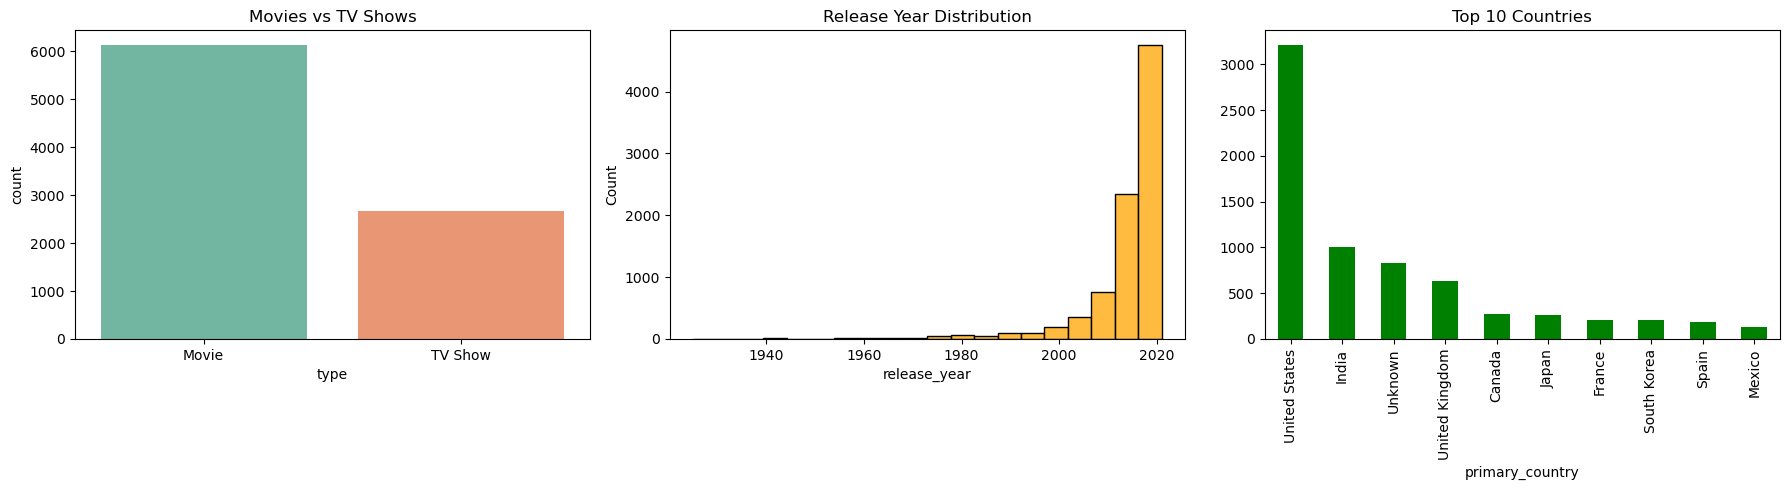

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,5))

# 1. Movies vs TV Shows
plt.subplot(1,3,1)
sns.countplot(x='type', data=df, hue='type', palette='Set2', legend=False)
plt.title('Movies vs TV Shows')

# 2. Release Year Distribution
plt.subplot(1,3,2)
sns.histplot(df['release_year'], bins=20, color='orange')
plt.title('Release Year Distribution')

# 3. Top 10 Countries
plt.subplot(1,3,3)
df['primary_country'].value_counts().head(10).plot(
    kind='bar',
    color='green'
)
plt.title('Top 10 Countries')

plt.tight_layout()
plt.show()

- as we can see that movies count is too greater then tv shows in netflix 
- in which mosly of the movies release year is between 2010-2020
- and mostly movies primary country is united states 

C:\Users\priyanshu sahu\AppData\Local\Temp\ipykernel_6148\495190275.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


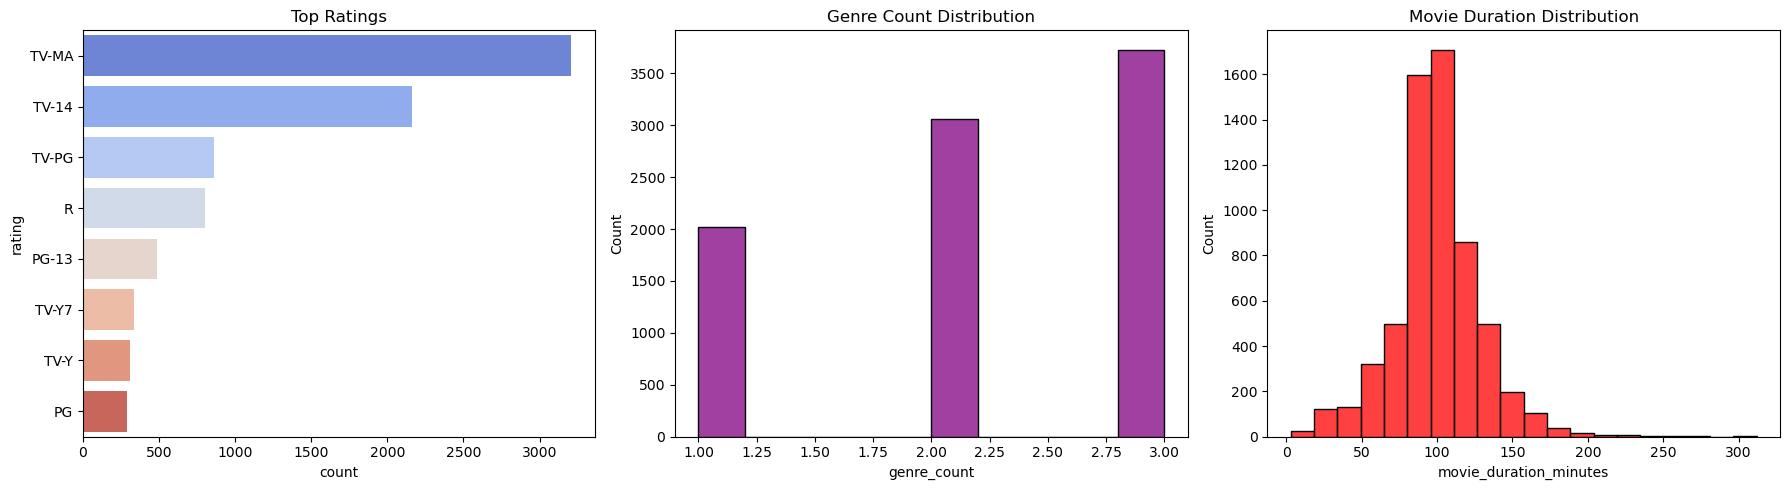

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,5))

# 1. Rating Distribution
plt.subplot(1,3,1)
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index[:8],
    palette='coolwarm'
)
plt.title('Top Ratings')

# 2. Genre Count Distribution
plt.subplot(1,3,2)
sns.histplot(df['genre_count'], bins=10, color='purple')
plt.title('Genre Count Distribution')

# 3. Movie Duration Distribution
plt.subplot(1,3,3)
sns.histplot(df['movie_duration_minutes'], bins=20, color='red')
plt.title('Movie Duration Distribution')

plt.tight_layout()
plt.show()

- as we can see that most of the rating audience is fro  telvision  audience mature audience , or of age 14 or above
- most of the movies 3 genre ki hai ( gen re means category or type of the movie or a tv show )
- most of the movies lies in 100  minutes of duration time 

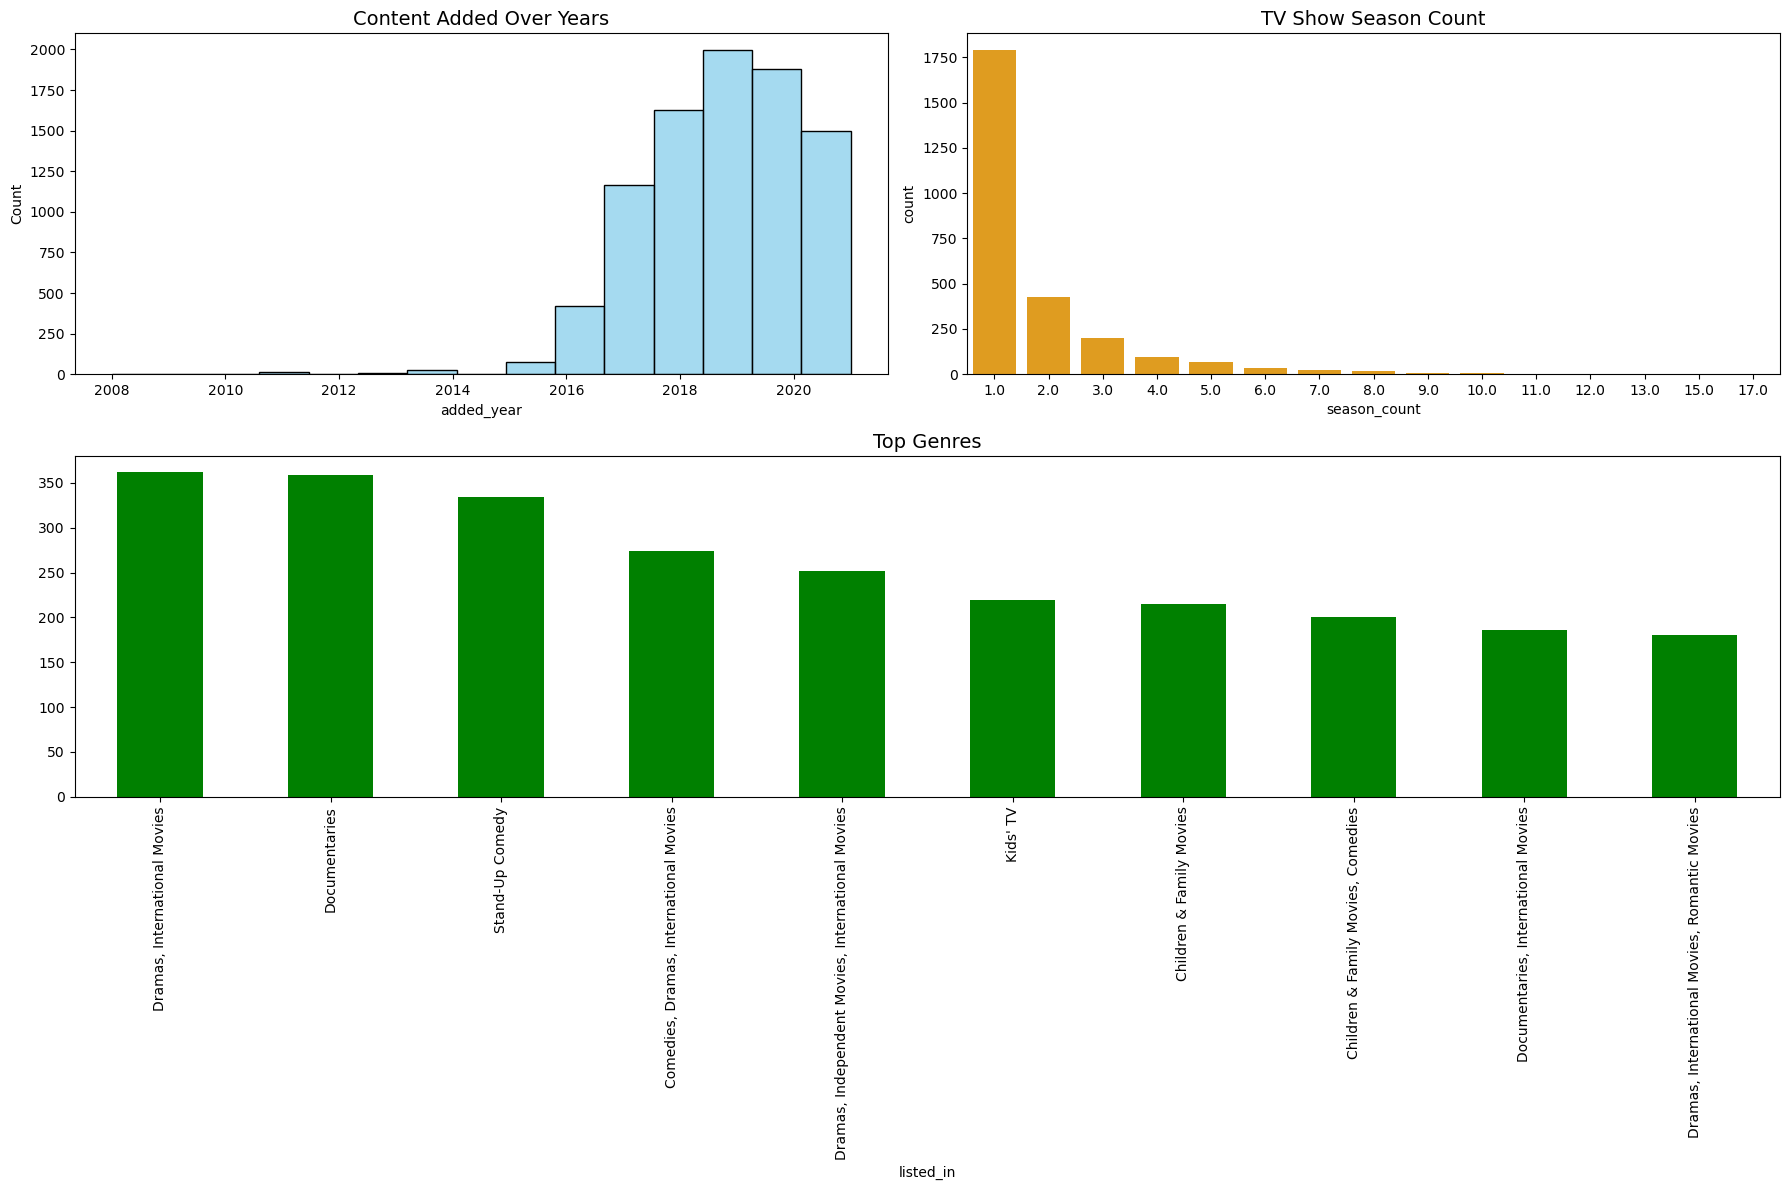

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

# 1. Added Year Distribution
plt.subplot(2,2,1)
sns.histplot(df['added_year'], bins=15, color='skyblue')
plt.title('Content Added Over Years', fontsize=14)

# 2. TV Show Season Count
plt.subplot(2,2,2)
sns.countplot(
    x='season_count',
    data=df,
    color='orange'
)
plt.title('TV Show Season Count', fontsize=14)

# 3. Top Genres (Below)
plt.subplot(2,1,2)
df['listed_in'].value_counts().head(10).plot(
    kind='bar',
    color='green'
)
plt.title('Top Genres', fontsize=14)

plt.tight_layout()
plt.show()

- as we can see most of the content added in year btw 2017-2021
- and max no content have only one seasons
- in which content is of different genres 

# Bivariate analysis 

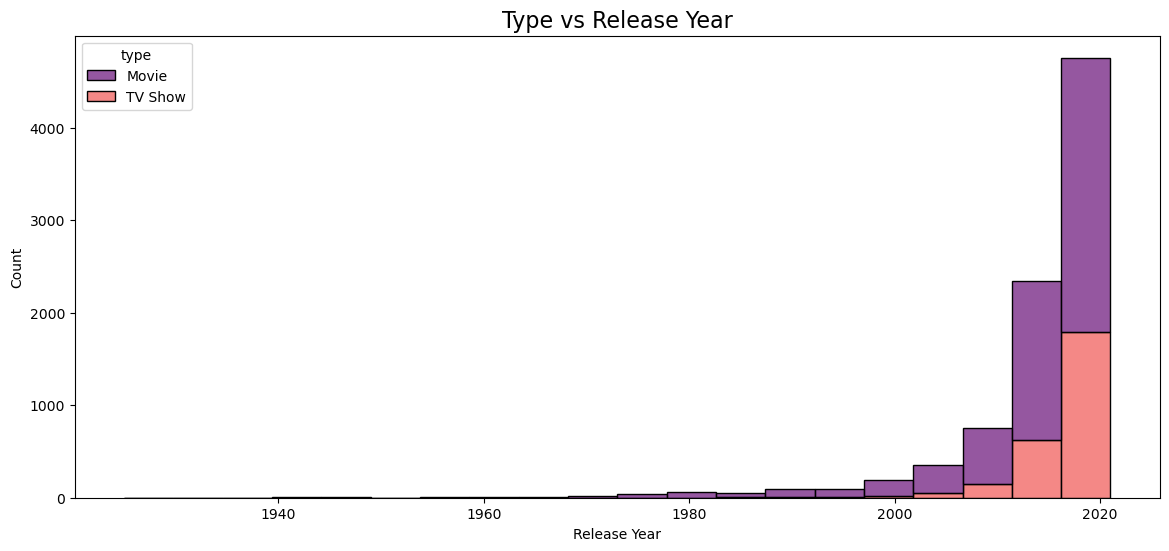

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.histplot(
    data=df,
    x='release_year',
    hue='type',
    bins=20,
    multiple='stack',
    palette='magma'
)

plt.title('Type vs Release Year', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

- 2015 ke baad Netflix content rapidly increase hua.
- Movies ka count har year me TV Shows se zyada hai.
- Recent years me TV Shows ka growth bhi increase hua hai.

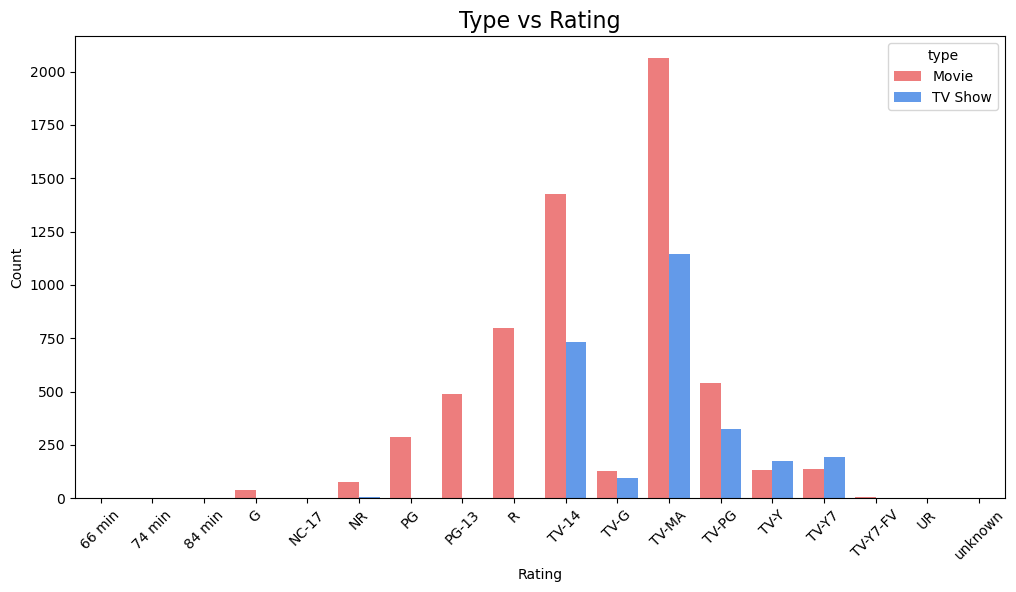

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    x='rating',
    hue='type',
    data=df,
    palette=['#FF6B6B', '#4D96FF']
)

plt.title('Type vs Rating', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

- Movies are more common than TV Shows in most rating categories.
- TV-MA and TV-14 are the most frequent ratings.
- Netflix mainly focuses on mature and teen audience content.

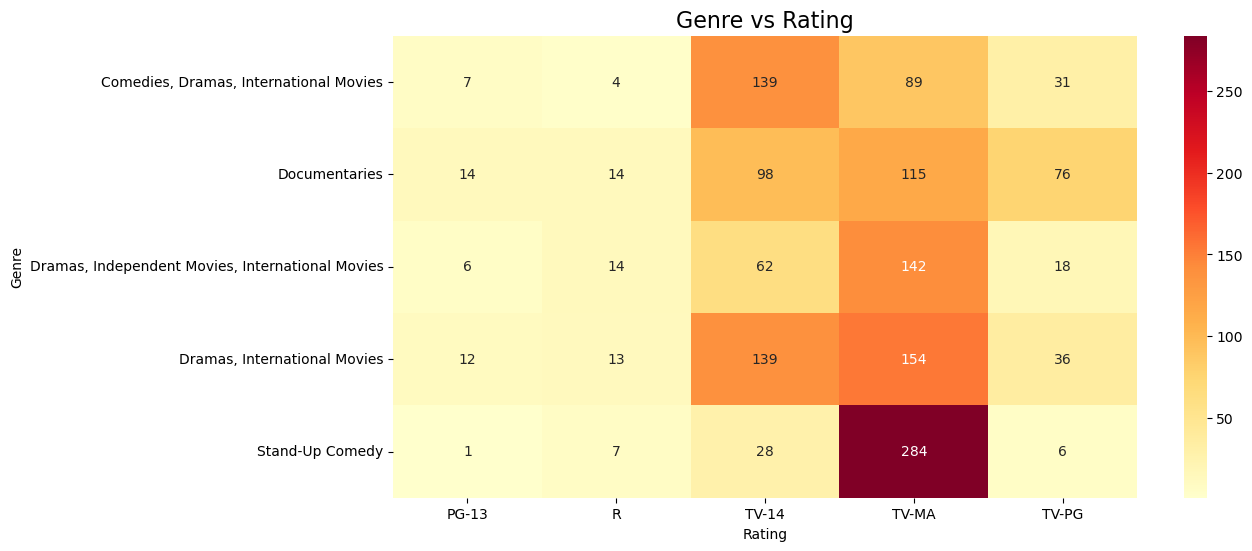

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Top genres and ratings
top_genres = df['listed_in'].value_counts().head(5).index
top_ratings = df['rating'].value_counts().head(5).index

# Filter data
temp = df[
    (df['listed_in'].isin(top_genres)) &
    (df['rating'].isin(top_ratings))
]

# Pivot table
pivot = pd.crosstab(temp['listed_in'], temp['rating'])

# Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='d'
)

plt.title('Genre vs Rating', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Genre')

plt.show()

- Darker colors show higher content count.
- TV-MA and TV-14 ratings dominate most genres.
- Drama and International Movies contain the highest mature audience content.
- Heatmap makes comparison easier and more visually clear than countplots.

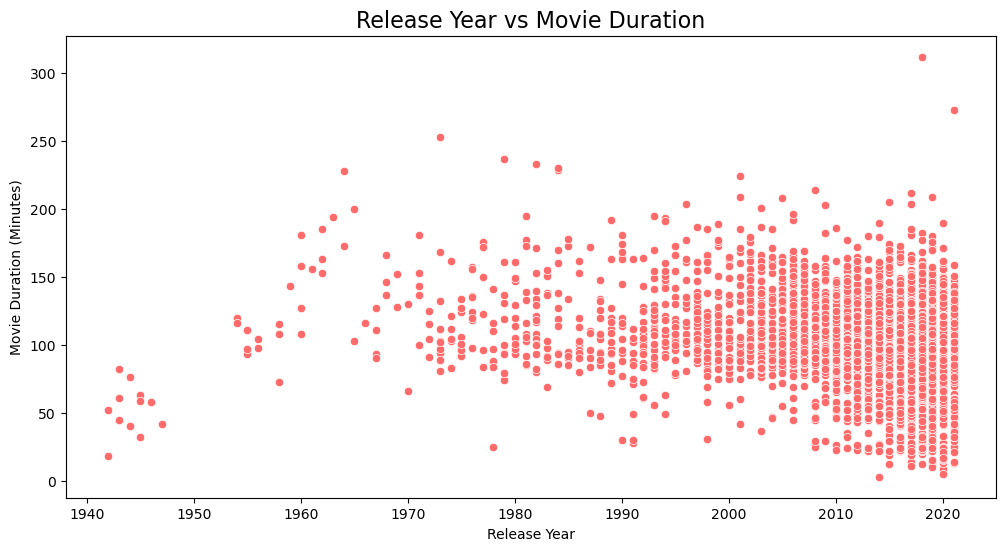

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='release_year',
    y='movie_duration_minutes',
    data=df,
    color='#FF6B6B'
)

plt.title('Release Year vs Movie Duration', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Movie Duration (Minutes)')

plt.show()

- Most Netflix movies are between 80–120 minutes long.
- Movie duration has remained fairly consistent over the years.
- Recent years contain a higher number of movie releases on Netflix.which means peoples using online platform from the past recent years 

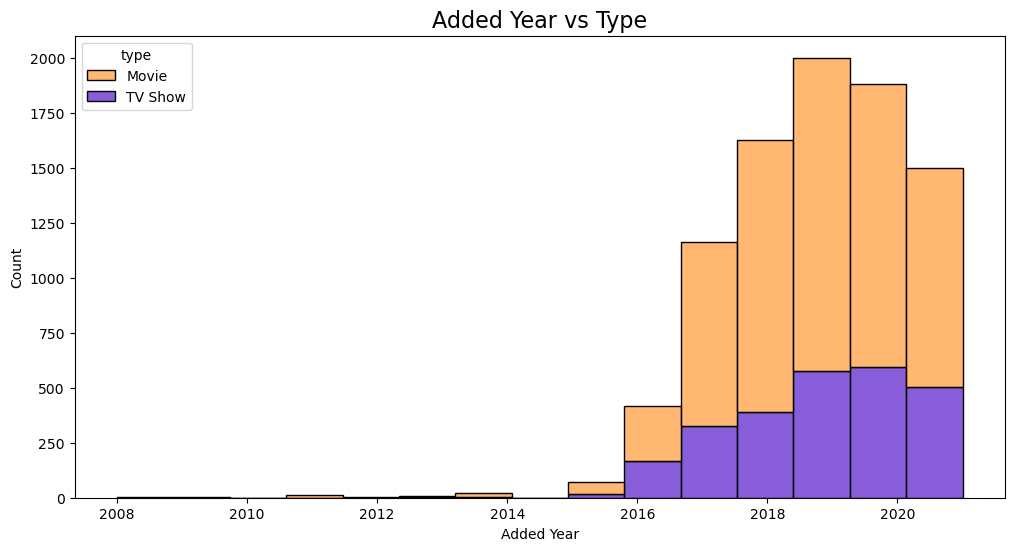

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='added_year',
    hue='type',
    multiple='stack',
    bins=15,
    palette=['#FF9F43', '#5F27CD']
)

plt.title('Added Year vs Type', fontsize=16)
plt.xlabel('Added Year')
plt.ylabel('Count')

plt.show()

- Netflix content additions increased rapidly after 2015.
- Movies are added more frequently than TV Shows.
- Recent years show significant growth in both content types.

C:\Users\priyanshu sahu\AppData\Local\Temp\ipykernel_6148\1160460189.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


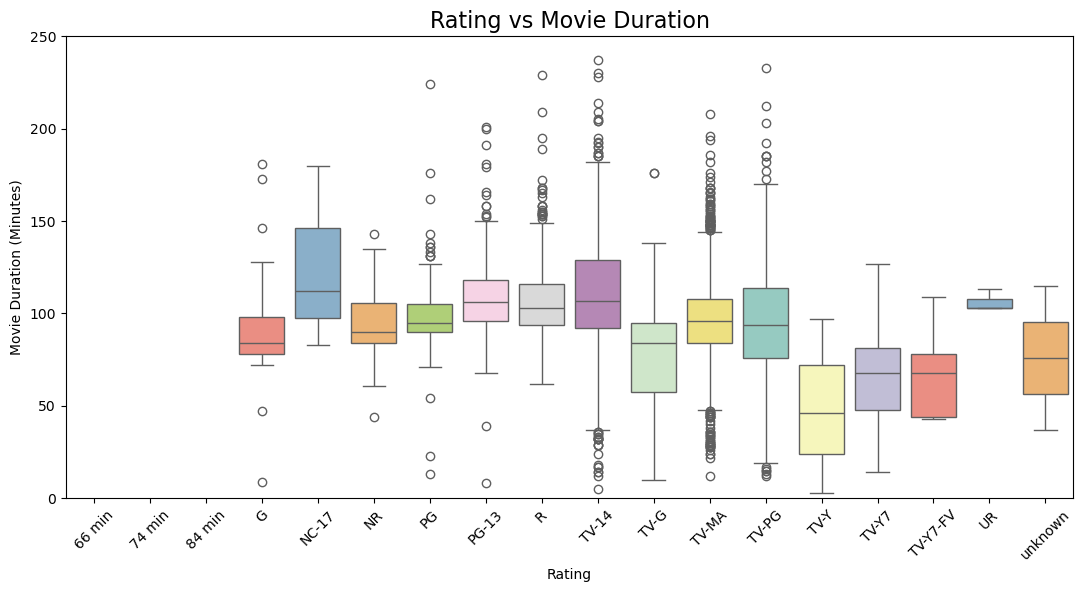

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13,6))

sns.boxplot(
    x='rating',
    y='movie_duration_minutes',
    data=df,
    palette='Set3'
)

plt.title('Rating vs Movie Duration', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Movie Duration (Minutes)')

plt.xticks(rotation=45)
plt.ylim(0,250)

plt.show()

- Most movies are between 80–120 minutes long.
- Different ratings have slightly different duration distributions.
- Some ratings contain very long-duration movies (outliers).
- TV-MA and PG-13 categories contain a large spread of movie durations.

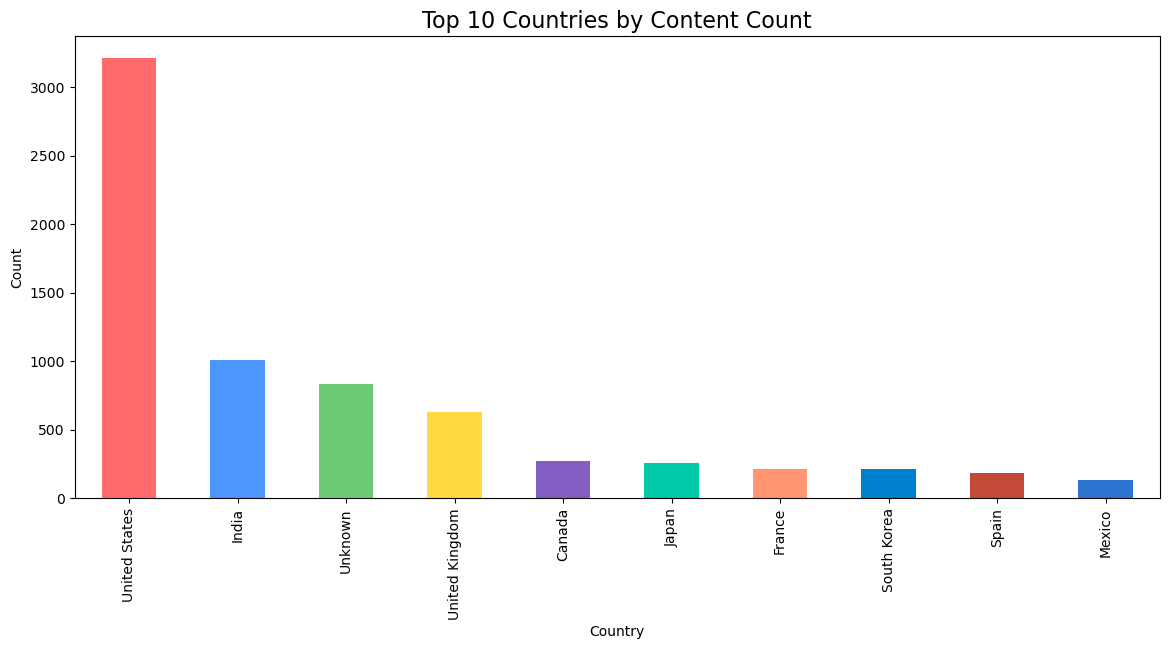

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

df['primary_country'].value_counts().head(10).plot(
    kind='bar',
    color=['#FF6B6B','#4D96FF','#6BCB77','#FFD93D',
           '#845EC2','#00C9A7','#FF9671','#0081CF',
           '#C34A36','#2C73D2']
)

plt.title('Top 10 Countries by Content Count', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

- United States dominates Netflix content.
- India is also one of the top contributors.
- Few countries contribute most of the Netflix library.

# Multivariate analysis

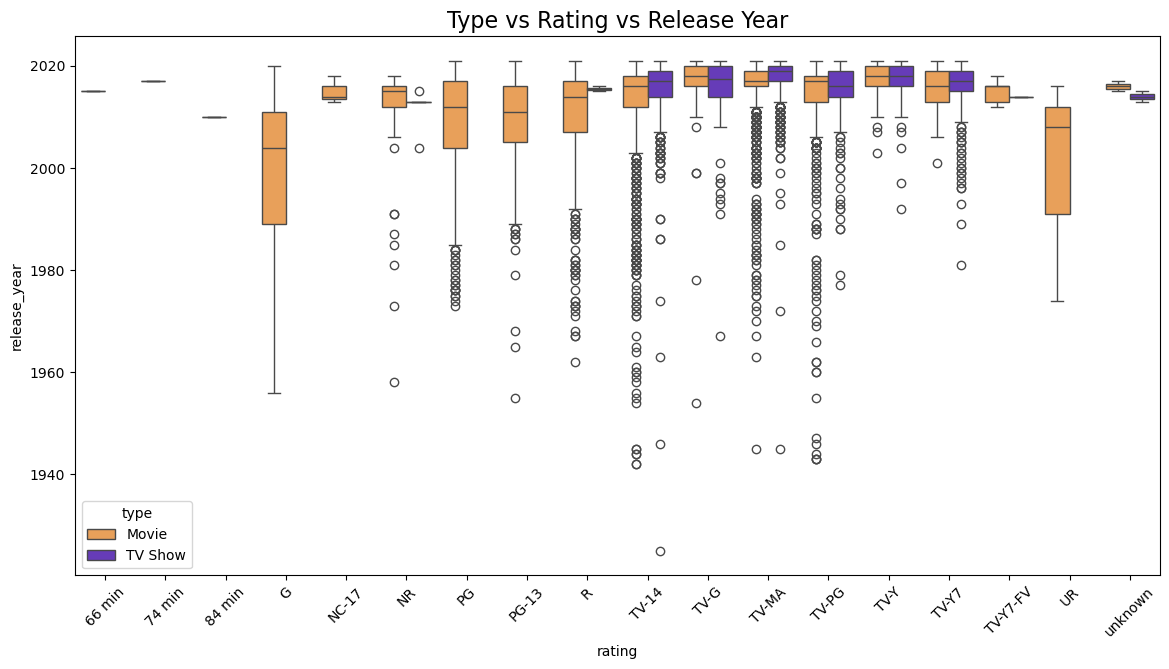

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.boxplot(
    x='rating',
    y='release_year',
    hue='type',
    data=df,
    palette=['#FF9F43', '#5F27CD']
)

plt.title('Type vs Rating vs Release Year', fontsize=16)

plt.xticks(rotation=45)

plt.show()

- TV-MA and TV-14 ratings are dominant in recent years.
- Movies are more common than TV Shows across most ratings.
- Netflix content growth increased significantly after 2015.

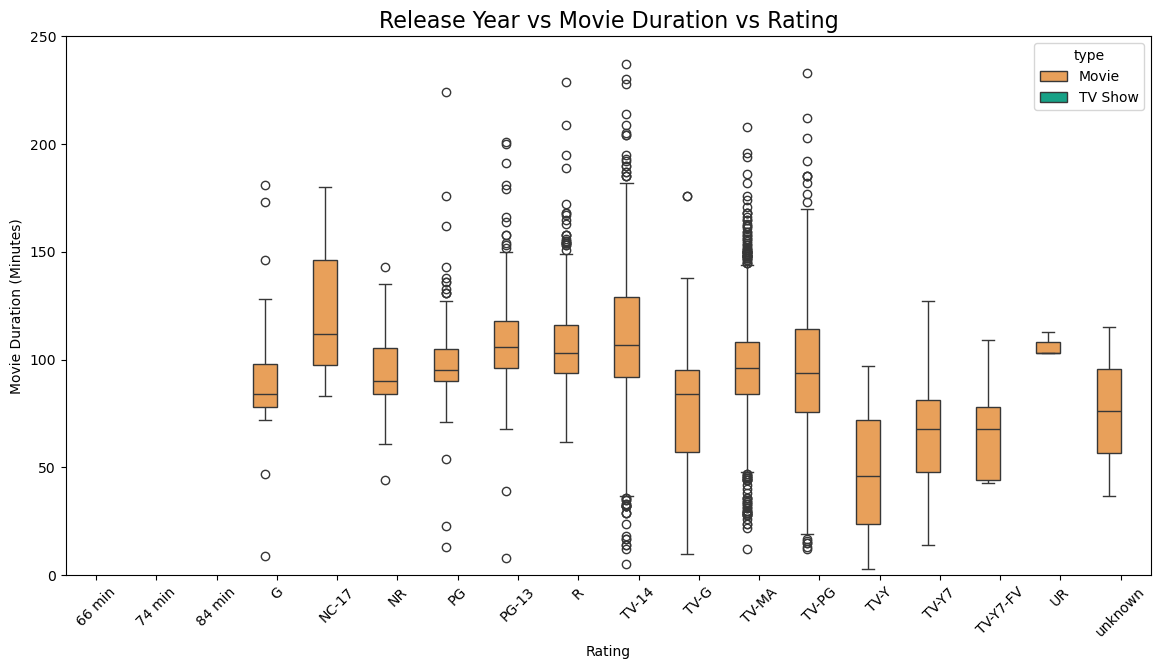

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.boxplot(
    x='rating',
    y='movie_duration_minutes',
    hue='type',
    data=df,
    palette=['#FF9F43', '#00B894']
)

plt.title('Release Year vs Movie Duration vs Rating', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Movie Duration (Minutes)')

plt.xticks(rotation=45)
plt.ylim(0,250)

plt.show()

- Different ratings have different movie duration ranges.
- Movies generally have longer durations than TV Shows.
- TV-MA and PG-13 categories contain the widest spread of durations.
- Most content duration lies between 80–120 minutes.

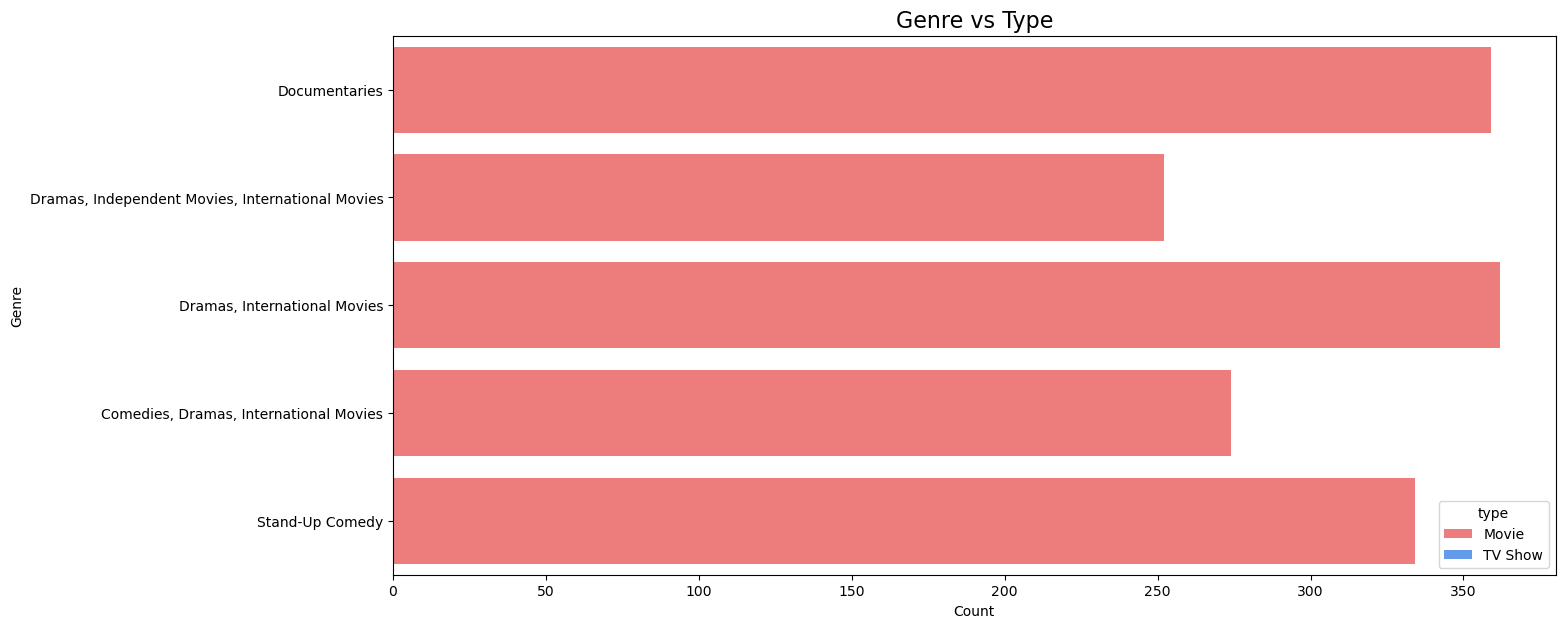

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 genres
top_genres = df['listed_in'].value_counts().head(5).index

filtered_df = df[df['listed_in'].isin(top_genres)]

plt.figure(figsize=(15,7))

sns.countplot(
    y='listed_in',
    hue='type',
    data=filtered_df,
    palette=['#FF6B6B', '#4D96FF']
)

plt.title('Genre vs Type', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

- Movies dominate most genres on Netflix.
- Drama and International Movies have the highest content count.
- TV Shows are fewer compared to Movies in almost every genre.
- Different colors make Movie vs TV Show comparison easy to understand.

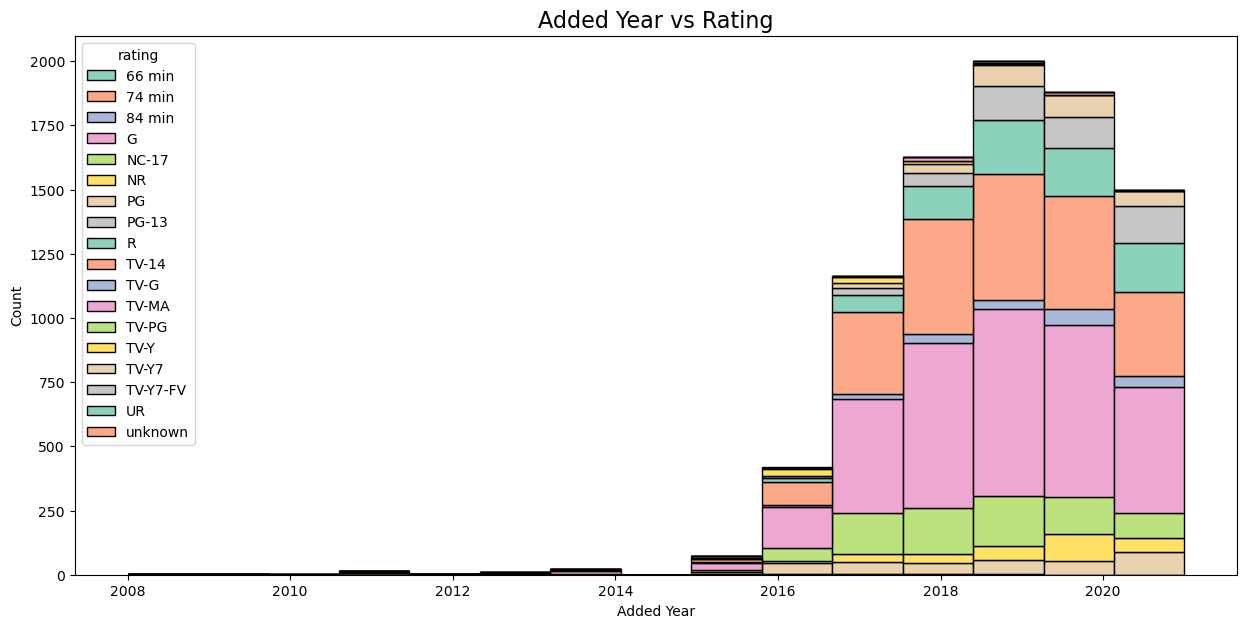

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,7))

sns.histplot(
    data=df,
    x='added_year',
    hue='rating',
    multiple='stack',
    bins=15,
    palette='Set2'
)

plt.title('Added Year vs Rating', fontsize=16)
plt.xlabel('Added Year')
plt.ylabel('Count')

plt.show()


- Netflix added more content after 2015.
- TV-MA and TV-14 ratings increased rapidly in recent years.
- Mature audience content dominates Netflix additions.
- Different colors make rating comparison easier to understand.

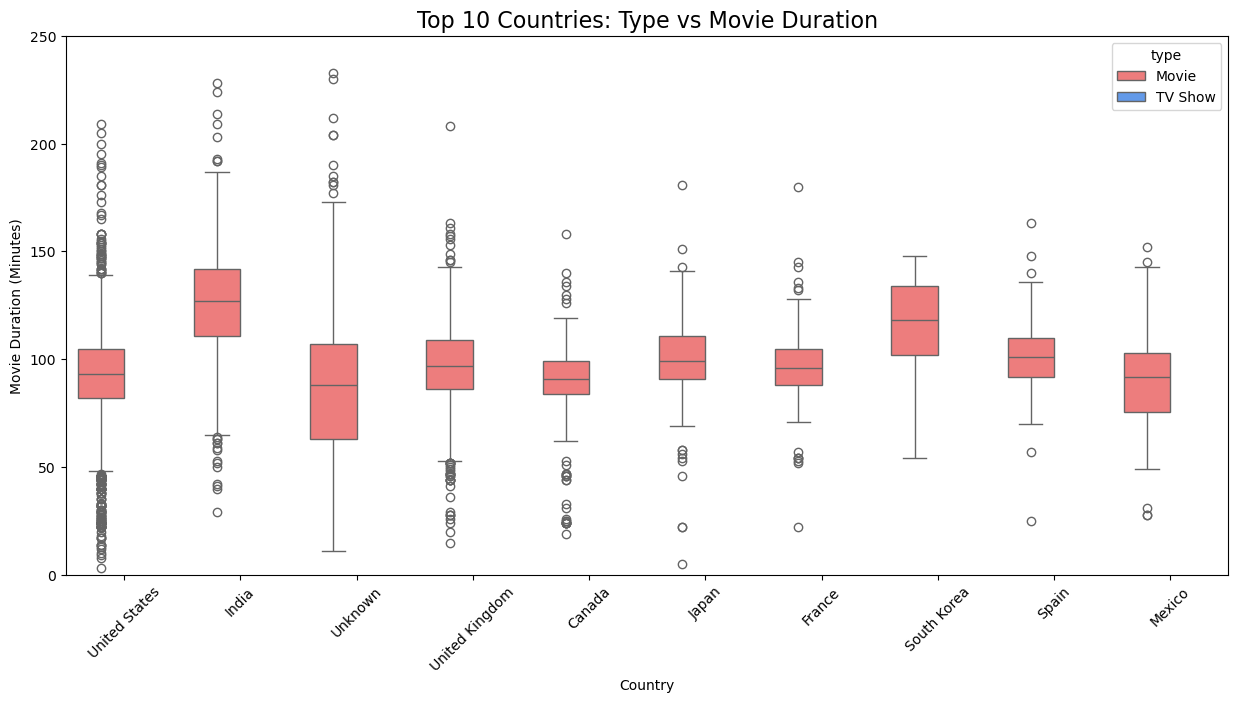

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 countries
top_10 = df['primary_country'].value_counts().head(10).index.tolist()

# Filter only top 10 countries
filtered_df = df[df['primary_country'].isin(top_10)]

plt.figure(figsize=(15,7))

sns.boxplot(
    data=filtered_df,
    x='primary_country',
    y='movie_duration_minutes',
    hue='type',
    order=top_10,   # Important
    palette=['#FF6B6B', '#4D96FF']
)

plt.title('Top 10 Countries: Type vs Movie Duration', fontsize=16)

plt.xlabel('Country')
plt.ylabel('Movie Duration (Minutes)')

plt.xticks(rotation=45)
plt.ylim(0,250)

plt.show()

- Different countries show different movie duration patterns on Netflix.
- Movies generally have longer durations than TV Shows across all countries.
- United States and India have the widest spread of movie durations.
- Most movie durations are concentrated between 80–120 minutes.
- Some countries contain a few very long-duration movies, which appear as outliers.

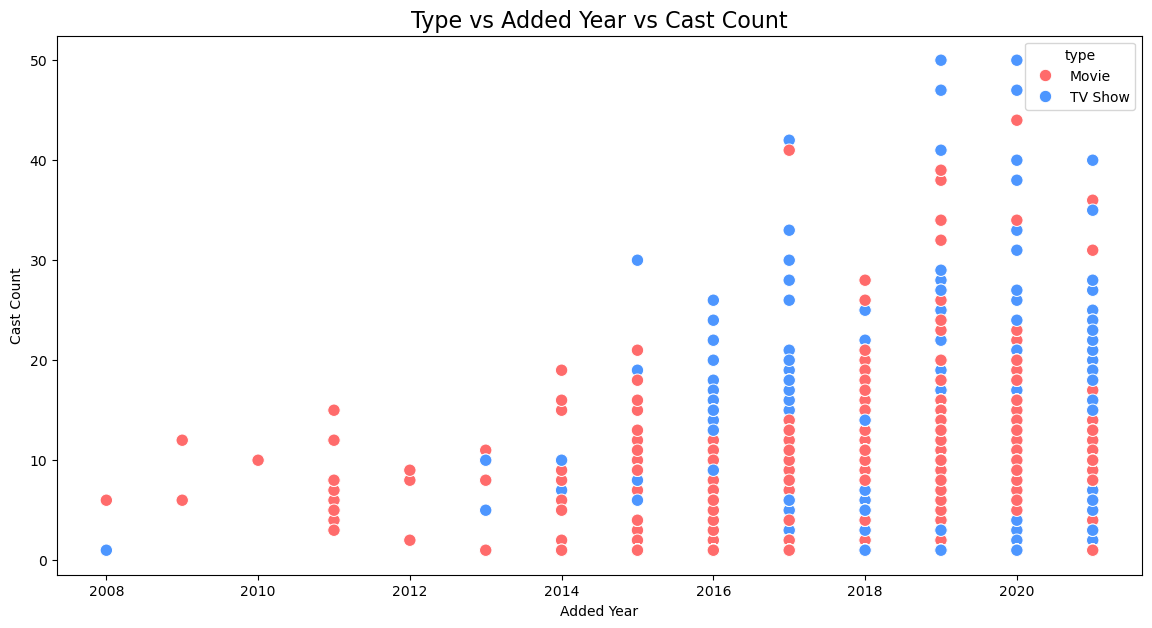

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.scatterplot(
    x='added_year',
    y='cast_count',
    hue='type',
    data=df,
    palette=['#FF6B6B', '#4D96FF'],
    s=80
)

plt.title('Type vs Added Year vs Cast Count', fontsize=16)

plt.xlabel('Added Year')
plt.ylabel('Cast Count')

plt.show()

- Recent Netflix content contains larger cast sizes.
- Movies generally have higher cast counts than TV Shows.
- Most content contains a moderate number of cast members.

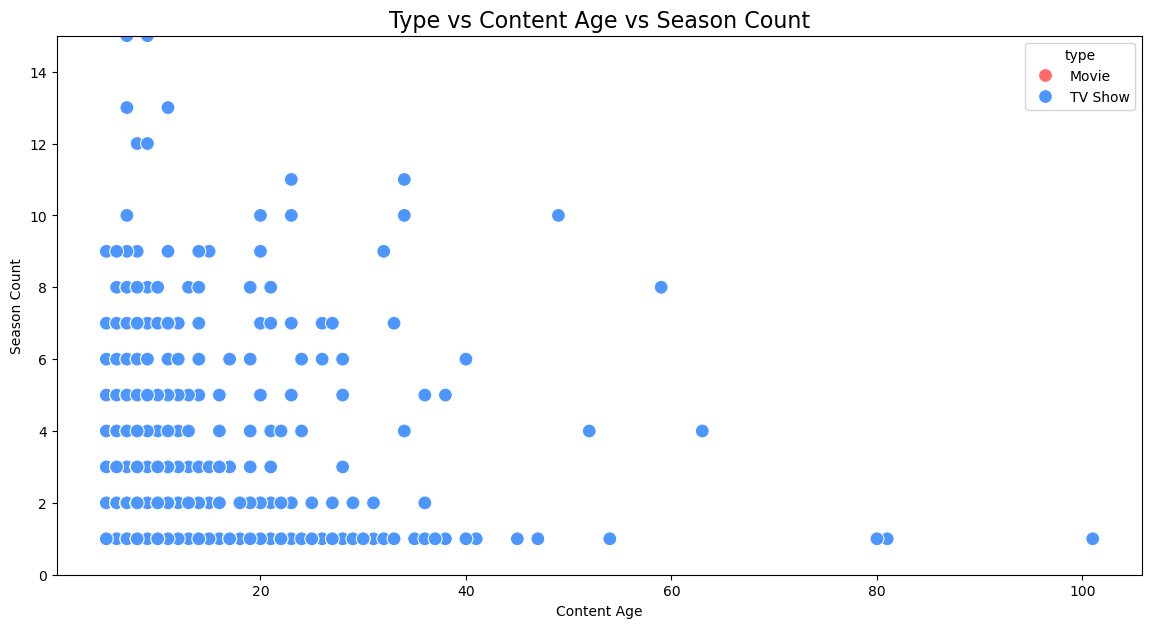

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.scatterplot(
    data=df,
    x='content_age',
    y='season_count',
    hue='type',
    palette=['#FF6B6B', '#4D96FF'],
    s=100
)

plt.title('Type vs Content Age vs Season Count', fontsize=16)

plt.xlabel('Content Age')
plt.ylabel('Season Count')

plt.ylim(0,15)

plt.show()

- Older TV Shows generally contain more seasons.
- Movies mostly have no season count, while TV Shows dominate higher season values.
- Most TV Shows on Netflix contain 1–3 seasons.
- Recent content generally has fewer seasons compared to older shows.

# Overall insight from complete analysis 
- Movies dominate Netflix content compared to TV Shows.
- TV-MA and TV-14 are the most common ratings on Netflix.
- Netflix mainly targets adult and teenage audiences.
- Drama and International Movies are the most popular genres.
- Most movies have durations between 80–120 minutes.
- TV Shows usually contain only 1–3 seasons.
- Netflix content growth increased rapidly after 2015.
- Recent years contain more diverse genres and ratings.
- United States and India are among the top content-producing countries.
- Mature content appears in almost every major genre.
- Multi-genre content has increased in recent years.
- Movies generally have longer durations than TV Shows.
- Some long-duration movies appear as outliers in the dataset.
- Netflix focuses more on globally consumable and binge-worthy content.
- International content became more important after Netflix’s global expansion.

# Overall Conclusion
- Netflix is strongly movie-dominated.
- Mature audience content performs best on the platform.
- Drama and International genres are key drivers of engagement.
- Netflix follows standard movie durations for better viewer retention.
- The platform rapidly expanded its content library in recent years.
- Netflix mainly focuses on scalable global entertainment content.

In [53]:
# Save cleaned dataset as CSV file

df.to_csv('cleaned_netflix_data.csv', index=False)

print("File saved successfully!")

File saved successfully!
